# Anchor-point regression — constrained variants & anomalies (Part 2 of 2)

Continuation of `anchor_regression.ipynb` (Part 1). Same anchor
set and panel; new topics:

* **Sections 10–11** — constrained regression: NNLS (`β ≥ 0`) and
  simplex (`β ≥ 0`, `Σβ = 1`). Quantify the R² cost of each
  constraint via `constraint_cost_heatmap`.
* **Sections 12–13** — convex-hull diagnostic
  (`convex_hull_flags`) and hedge-allocation tables
  (`beta_allocation_table`).
* **Sections 14–15** — rolling stability under NNLS / simplex
  and a unified three-mode metrics row.
* **Section 16** — `anomaly_report` for per-date anchor /
  residual anomaly flags and the `decoupling` monitoring signal.

Section numbering continues from Part 1 so cross-references match.
This notebook re-runs the setup cells from Part 1 (data load,
liquid universe, greedy k=4 anchor derivation) so it stands alone.


## Setup (Part 2 — replays Part 1 sections 0–2 + 7)


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import EXPIRY_LABELS, TENOR_LABELS, EXPIRY_RANK, TENOR_RANK
from pca import load_long, to_wide
from factors import (
    fit_ridge, fit_ridge_rolling, fit_nnls, fit_simplex,
    fit_nnls_rolling, fit_simplex_rolling,
    get_anchor_slice, residual_panel,
    greedy_anchor_select, r2_heatmap,
    constraint_cost_heatmap, convex_hull_flags, beta_allocation_table,
    beta_stability, anchor_metrics_row,
    anchor_zscore, residual_zscore, anomaly_report,
)

sns.set_theme(style="whitegrid")

rate = to_wide(load_long("../data/mock/rate.pkl")).diff().dropna()
print("rate diff:", rate.shape)

# Liquid universe (same definition as Part 1 section 1).
LIQUID_EXPIRIES = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "10Y", "15Y", "20Y"]
LIQUID_TENORS   = ["1Y", "2Y", "5Y", "10Y", "30Y"]
LIQUID_UNIVERSE = [(e, t) for e in LIQUID_EXPIRIES for t in LIQUID_TENORS]
LIQUID_SET = set(LIQUID_UNIVERSE)
FORBIDDEN = [c for c in rate.columns if c not in LIQUID_SET]

# Re-derive the greedy k=4 anchor set used throughout Part 2.
# Matches Part 1 section 7; re-running keeps the notebook self-contained.
greedy_history = greedy_anchor_select(rate, k=4, lam=1e-4, exclude=FORBIDDEN)
greedy_k4 = [h["anchor"] for h in greedy_history]
print(f"\ngreedy k=4 anchors (re-derived): {greedy_k4}")


rate diff: (499, 204)


greedy step 1/4: picked ('1Y', '2Y'), cumulative R² = 0.0105, marginal R² = 0.0105


greedy step 2/4: picked ('20Y', '30Y'), cumulative R² = 0.0205, marginal R² = 0.0100


greedy step 3/4: picked ('2Y', '10Y'), cumulative R² = 0.0302, marginal R² = 0.0097


greedy step 4/4: picked ('10Y', '2Y'), cumulative R² = 0.0397, marginal R² = 0.0095

greedy k=4 anchors (re-derived): [('1Y', '2Y'), ('20Y', '30Y'), ('2Y', '10Y'), ('10Y', '2Y')]


## 10. Constrained regression variants — NNLS and simplex

Sections 3–9 used unconstrained ridge regression: betas can be any
real number, positive or negative. That gives the tightest fit but
two awkward properties for an executable hedge:

1. **Negative betas** are perfectly valid in OLS but require shorting
   anchor instruments to hedge a long position in a target cell — fine
   for a swap book, weird for a vanilla portfolio.
2. **No interpretability constraint** on the loading vector: the
   sum and signs of betas have no a-priori meaning, so two equally
   good fits can give wildly different hedge ratios.

Two natural restrictions:

* **NNLS** (`fit_nnls`): require `β ≥ 0`. Long-only hedge.
* **Simplex** (`fit_simplex`): require `β ≥ 0` **and** `Σβ = 1`. Each
  cell's move is modelled as a *convex combination* of anchor moves —
  the strongest interpretability constraint: betas are a hedge
  allocation totalling 100% of the cell's notional.

All three modes are run below on the greedy K=4 anchor set, with the
explained-variance cost of each constraint layer made explicit.


### 10a. NNLS vs ridge — does non-negativity alone cost much?


greedy k=4 anchors: [('1Y', '2Y'), ('20Y', '30Y'), ('2Y', '10Y'), ('10Y', '2Y')]
mean R²  ridge: 0.0382
mean R²  NNLS:  0.0362
R² gap (ridge − NNLS):  mean=+0.0020, max=+0.0218



cells where forbidding negative betas costs the most:
expiry  tenor
1Y      20Y      0.0218
20Y     20Y      0.0193
10Y     20Y      0.0165
1Y      1Y       0.0145
9M      30Y      0.0128
dtype: float64


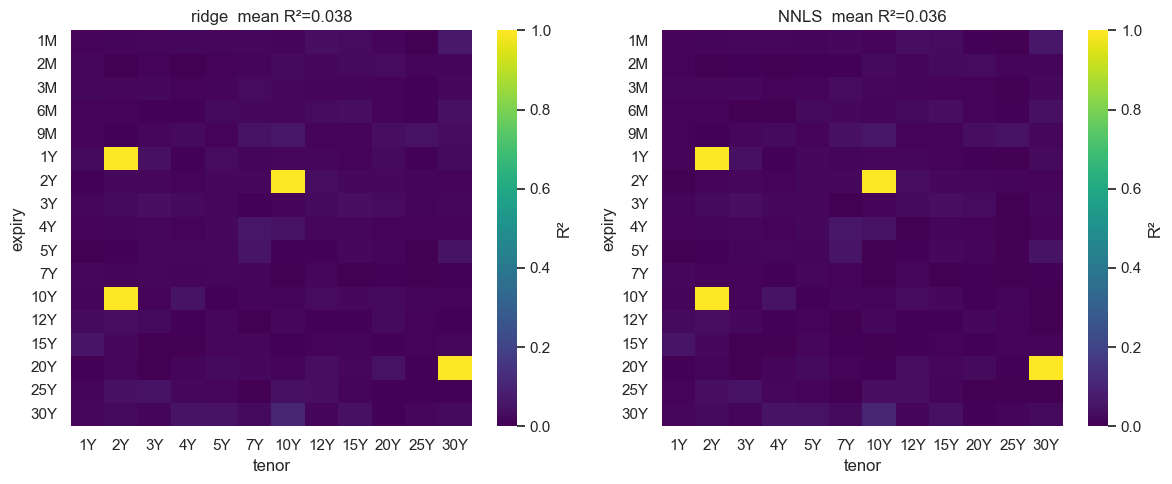

In [2]:
from factors import fit_nnls, fit_simplex

greedy_k4 = [h["anchor"] for h in greedy_history[:4]]
print("greedy k=4 anchors:", greedy_k4)

ridge_betas_k4 = fit_ridge(rate, greedy_k4, lam=1e-4)
nnls_betas_k4  = fit_nnls(rate, greedy_k4)

r2_ridge_k4 = r2_heatmap(rate, greedy_k4, lam=1e-4)
# r2_heatmap is ridge-only by API; build the NNLS one inline.
def _r2_grid(betas):
    am = get_anchor_slice(rate, greedy_k4)
    resid = residual_panel(rate, am, betas)
    aligned = rate.loc[resid.index, resid.columns]
    ss_r = (resid ** 2).sum(axis=0)
    ss_t = ((aligned - aligned.mean()) ** 2).sum(axis=0)
    r2 = 1.0 - ss_r / ss_t.where(ss_t > 0, 1.0)
    grid = r2.unstack(level="tenor")
    return grid.reindex(
        index=[e for e in EXPIRY_LABELS if e in grid.index],
        columns=[t for t in TENOR_LABELS if t in grid.columns],
    )

r2_nnls_k4 = _r2_grid(nnls_betas_k4)
print(f"mean R²  ridge: {r2_ridge_k4.values.mean():.4f}")
print(f"mean R²  NNLS:  {r2_nnls_k4.values.mean():.4f}")
print(f"R² gap (ridge − NNLS):  mean={float((r2_ridge_k4 - r2_nnls_k4).values.mean()):+.4f}, "
      f"max={float((r2_ridge_k4 - r2_nnls_k4).values.max()):+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vmin, vmax = 0.0, 1.0
sns.heatmap(r2_ridge_k4, ax=axes[0], cmap="viridis", vmin=vmin, vmax=vmax,
            cbar_kws={"label": "R²"})
axes[0].set_title(f"ridge  mean R²={r2_ridge_k4.values.mean():.3f}")
axes[0].set_xlabel("tenor"); axes[0].set_ylabel("expiry")
sns.heatmap(r2_nnls_k4, ax=axes[1], cmap="viridis", vmin=vmin, vmax=vmax,
            cbar_kws={"label": "R²"})
axes[1].set_title(f"NNLS  mean R²={r2_nnls_k4.values.mean():.3f}")
axes[1].set_xlabel("tenor"); axes[1].set_ylabel("expiry")
fig.tight_layout()

# Identify worst-case cells: ridge R² much higher than NNLS R²
gap = (r2_ridge_k4 - r2_nnls_k4).stack()
top_drops = gap.sort_values(ascending=False).head(5)
print("\ncells where forbidding negative betas costs the most:")
print(top_drops.round(4))


In an OLS world a negative beta is just "this cell's move opposes
the anchor's move on average". Forcing `β ≥ 0` zeroes those terms,
so any cell that was *partly explained by a negative loading* in
ridge loses that fit. Cells appearing in the top-drops table are
the ones where negative betas were doing real work — a hedging red
flag because a long-only hedge there will systematically mis-match.


### 11a. Simplex regression — `β ≥ 0` and `Σβ = 1`

Adds the sum-to-one constraint on top of NNLS. Each cell's move is
modelled as a convex combination of anchor moves, which is a much
stronger structural assumption: the cell's move *cannot* have larger
amplitude than the largest anchor move and *cannot* point in a
direction outside the span of the anchors.


       r2_ridge   r2_nnls  r2_simplex
count  204.0000  204.0000    204.0000
mean     0.0382    0.0362     -0.1629
std      0.1370    0.1374      0.1778
min      0.0014    0.0001     -0.3728
25%      0.0104    0.0071     -0.2314
50%      0.0163    0.0135     -0.1860
75%      0.0251    0.0234     -0.1402
max      1.0000    1.0000      1.0000


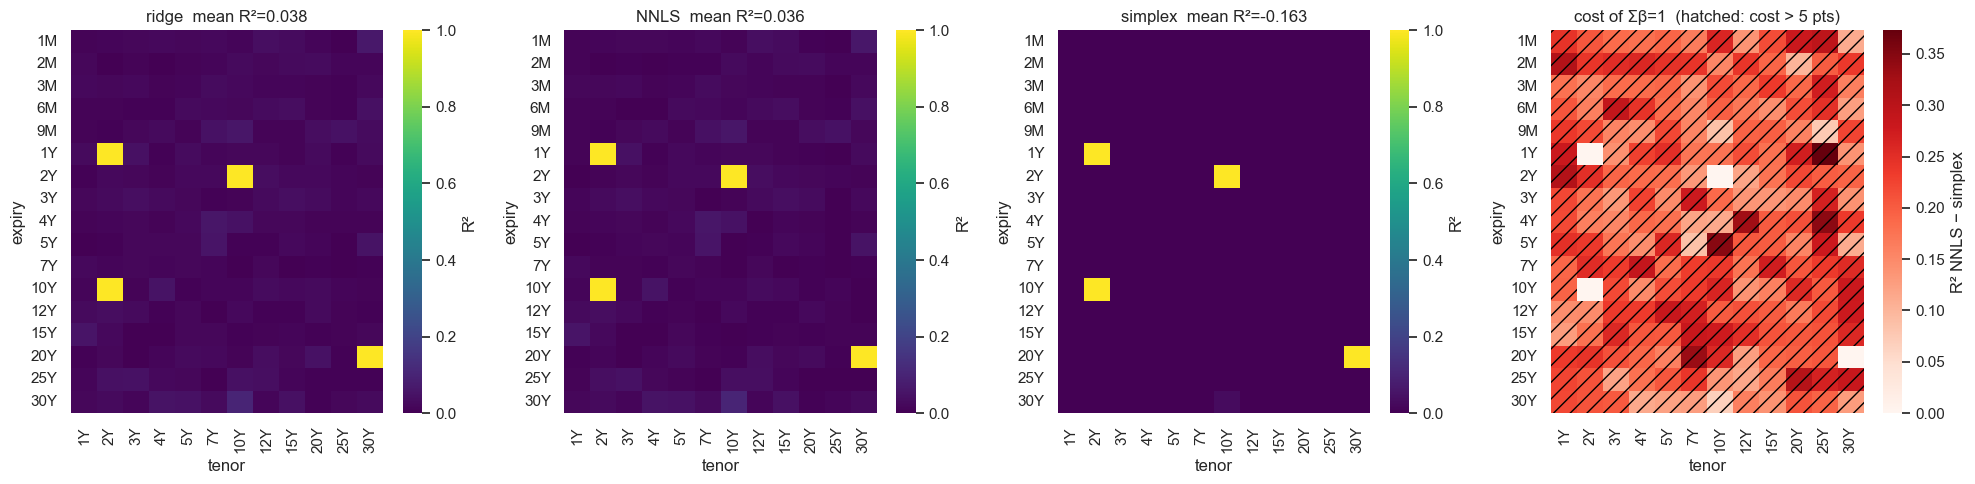

In [3]:
from factors import constraint_cost_heatmap

cost_df = constraint_cost_heatmap(rate, greedy_k4, lam=1e-4)
print(cost_df.describe().round(4))

# Build per-mode grids
def _to_grid(series):
    g = series.unstack(level="tenor")
    return g.reindex(
        index=[e for e in EXPIRY_LABELS if e in g.index],
        columns=[t for t in TENOR_LABELS if t in g.columns],
    )

g_ridge   = _to_grid(cost_df["r2_ridge"])
g_nnls    = _to_grid(cost_df["r2_nnls"])
g_simplex = _to_grid(cost_df["r2_simplex"])
g_simplex_cost = g_nnls - g_simplex  # cost of the Σβ=1 constraint

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, grid, title in [
    (axes[0], g_ridge,   f"ridge  mean R²={g_ridge.values.mean():.3f}"),
    (axes[1], g_nnls,    f"NNLS  mean R²={g_nnls.values.mean():.3f}"),
    (axes[2], g_simplex, f"simplex  mean R²={g_simplex.values.mean():.3f}"),
]:
    sns.heatmap(grid, ax=ax, cmap="viridis", vmin=0, vmax=1,
                cbar_kws={"label": "R²"})
    ax.set_title(title); ax.set_xlabel("tenor"); ax.set_ylabel("expiry")

sns.heatmap(g_simplex_cost, ax=axes[3], cmap="Reds", vmin=0,
            cbar_kws={"label": "R² NNLS − simplex"})
# Hatched overlay on cells where the cost exceeds 5 pts
mask = (g_simplex_cost > 0.05).values
for (i, j), flagged in np.ndenumerate(mask):
    if flagged:
        axes[3].add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                         hatch='//', edgecolor='black',
                                         linewidth=0))
axes[3].set_title(f"cost of Σβ=1  (hatched: cost > 5 pts)")
axes[3].set_xlabel("tenor"); axes[3].set_ylabel("expiry")
fig.tight_layout()


### 12a. Where does the convex-hull assumption break down?

`convex_hull_flags` returns `True` exactly where adding the
`Σβ=1` constraint costs more than 5 R² points on top of NNLS. Those
cells are the ones whose move amplitude or direction cannot be
written as a convex combination of the chosen anchors — i.e. they
sit *outside* the anchors' convex hull on the cube.

The remedy is usually to add an anchor that *spans* that region. We
greedy-pick the single best additional cell below.


convex-hull breach: 200 / 204 cells (100.0% of non-anchor cells)


greedy step 1/1: picked ('15Y', '1Y'), cumulative R² = 0.0102, marginal R² = 0.0102

best single additional anchor: ('15Y', '1Y')  marginal R² = 0.0102


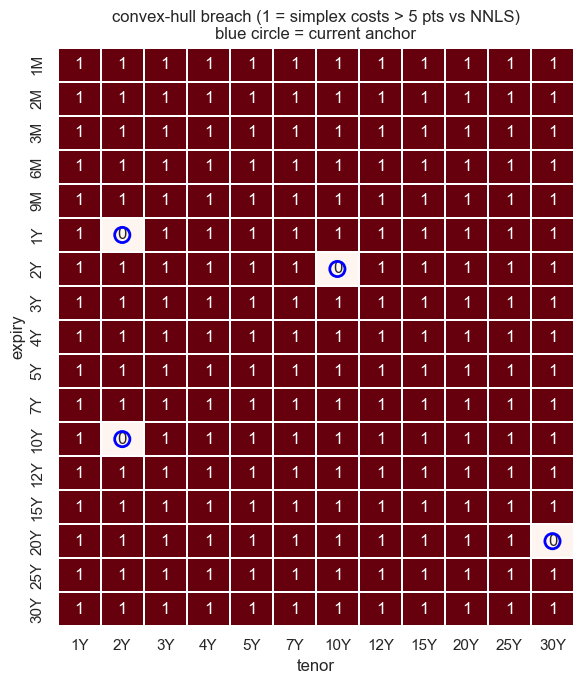

In [4]:
from factors import convex_hull_flags

flags_k4 = convex_hull_flags(rate, greedy_k4)
n_breach = int(flags_k4.values.sum())
total = flags_k4.size
non_anchor_total = total - len(greedy_k4)
print(f"convex-hull breach: {n_breach} / {total} cells "
      f"({n_breach / non_anchor_total:.1%} of non-anchor cells)")

fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(flags_k4.astype(int), ax=ax, cmap="Reds",
            cbar=False, linewidths=0.3, linecolor="white",
            annot=True, fmt="d")
# Mark current anchors with a dot
for (e, t) in greedy_k4:
    ax.scatter(TENOR_LABELS.index(t) + 0.5, EXPIRY_LABELS.index(e) + 0.5,
               s=120, marker="o", facecolor="none",
               edgecolor="blue", linewidth=2, zorder=10)
ax.set_title("convex-hull breach (1 = simplex costs > 5 pts vs NNLS)\n"
             "blue circle = current anchor")
ax.set_xlabel("tenor"); ax.set_ylabel("expiry")
fig.tight_layout()

# Best single additional anchor — exclude existing anchors + non-liquid cells
exclude_for_step5 = FORBIDDEN + greedy_k4
extra = greedy_anchor_select(rate, k=1, lam=1e-4, exclude=exclude_for_step5)
print(f"\nbest single additional anchor: {extra[0]['anchor']}  "
      f"marginal R² = {extra[0]['marginal_r2']:.4f}")


### 13a. Hedge-allocation table for representative cells

Each non-anchor cell's simplex beta row is a hedge recipe: how to
split unit notional in that cell across the K anchor instruments.
We pick 6 representative cells — high simplex R² (clean hedge),
near-boundary (simplex barely works), and worst R² (hedge breaks
down) — and print the allocation as a small table per cell.


In [5]:
from factors import beta_allocation_table

simplex_betas_k4 = fit_simplex(rate, greedy_k4)
alloc_full = beta_allocation_table(simplex_betas_k4, greedy_k4)

# Per-cell R² for sorting
am_k4 = get_anchor_slice(rate, greedy_k4)
resid_simplex = residual_panel(rate, am_k4, simplex_betas_k4)
aligned = rate.loc[resid_simplex.index, resid_simplex.columns]
ss_resid = (resid_simplex ** 2).sum(axis=0)
ss_total = ((aligned - aligned.mean()) ** 2).sum(axis=0)
r2_simplex_pc = 1.0 - ss_resid / ss_total.where(ss_total > 0, 1.0)

anchor_set = set(greedy_k4)
non_anchor_cells = [c for c in r2_simplex_pc.index if c not in anchor_set]
r2_non_anchor = r2_simplex_pc.loc[non_anchor_cells].sort_values()

# Pick: 2 best, 2 boundary (flagged by hull breach), 2 worst
flagged_cells = [
    (e, t) for e in flags_k4.index for t in flags_k4.columns
    if bool(flags_k4.loc[e, t]) and (e, t) not in anchor_set
]
flagged_r2 = r2_simplex_pc.loc[flagged_cells].sort_values()
two_boundary = flagged_r2.iloc[len(flagged_r2) // 2 - 1:len(flagged_r2) // 2 + 1].index.tolist() \
    if len(flagged_r2) >= 2 else flagged_r2.index.tolist()

two_best = r2_non_anchor.tail(2).index.tolist()
two_worst = r2_non_anchor.head(2).index.tolist()

pick = list(dict.fromkeys(two_best + two_boundary + two_worst))[:6]
print(f"showing {len(pick)} cells: best={two_best}, boundary={two_boundary}, worst={two_worst}\n")

for cell in pick:
    row = alloc_full.loc[cell] * 100  # %
    r2 = float(r2_simplex_pc.loc[cell])
    label = "anchor" if cell in anchor_set else ("hull-breach" if bool(flags_k4.loc[cell[0], cell[1]]) else "interior")
    print(f"{cell[0]}×{cell[1]}  ({label}, simplex R²={r2:.3f})")
    print(row.round(1).to_string())
    print()


showing 6 cells: best=[('9M', '25Y'), ('30Y', '10Y')], boundary=[('15Y', '5Y'), ('4Y', '15Y')], worst=[('1Y', '25Y'), ('5Y', '10Y')]

9M×25Y  (hull-breach, simplex R²=-0.030)
1Y|2Y      25.5
20Y|30Y    23.6
2Y|10Y     25.5
10Y|2Y     25.4

30Y×10Y  (hull-breach, simplex R²=0.031)
1Y|2Y      31.6
20Y|30Y    31.9
2Y|10Y      8.9
10Y|2Y     27.7

15Y×5Y  (hull-breach, simplex R²=-0.188)
1Y|2Y      17.5
20Y|30Y    24.5
2Y|10Y     26.5
10Y|2Y     31.5

4Y×15Y  (hull-breach, simplex R²=-0.186)
1Y|2Y      26.1
20Y|30Y    31.0
2Y|10Y     26.8
10Y|2Y     16.1

1Y×25Y  (hull-breach, simplex R²=-0.373)
1Y|2Y      23.9
20Y|30Y    27.8
2Y|10Y     24.2
10Y|2Y     24.2

5Y×10Y  (hull-breach, simplex R²=-0.346)
1Y|2Y      28.7
20Y|30Y    27.9
2Y|10Y     21.5
10Y|2Y     21.8



### 14a. Rolling beta stability under each constraint

Re-fit on rolling 126-day windows under NNLS and simplex, then look
at how much each (cell, anchor) hedge ratio drifts. The
non-negativity floor in NNLS / simplex can sometimes *stabilise*
betas vs unconstrained ridge (because the solver can't oscillate
across zero), or *destabilise* them (because a cell whose true beta
is near zero gets stuck on the bound).

To keep simplex rolling tractable on mock data, we restrict the
panel to the 50-cell liquid universe (= the only cells the desk
would actually hedge through these anchors). Real data, full cube:
budget ~10 min for the simplex rolling fit.


rolling fits on liquid panel: (499, 50)
running NNLS rolling...


running simplex rolling (slower)...


NNLS:    (373, 200) dates × (cells × anchors)
simplex: (373, 200) dates × (cells × anchors)

mean rolling-beta std per anchor:
  NNLS:
anchor
10Y|2Y     0.0539
1Y|2Y      0.0525
20Y|30Y    0.0504
2Y|10Y     0.0521
dtype: float64
  simplex:
anchor
10Y|2Y     0.0691
1Y|2Y      0.0712
20Y|30Y    0.0626
2Y|10Y     0.0685
dtype: float64



simplex (cell, anchor) pairs with rolling std > 0.3: 0


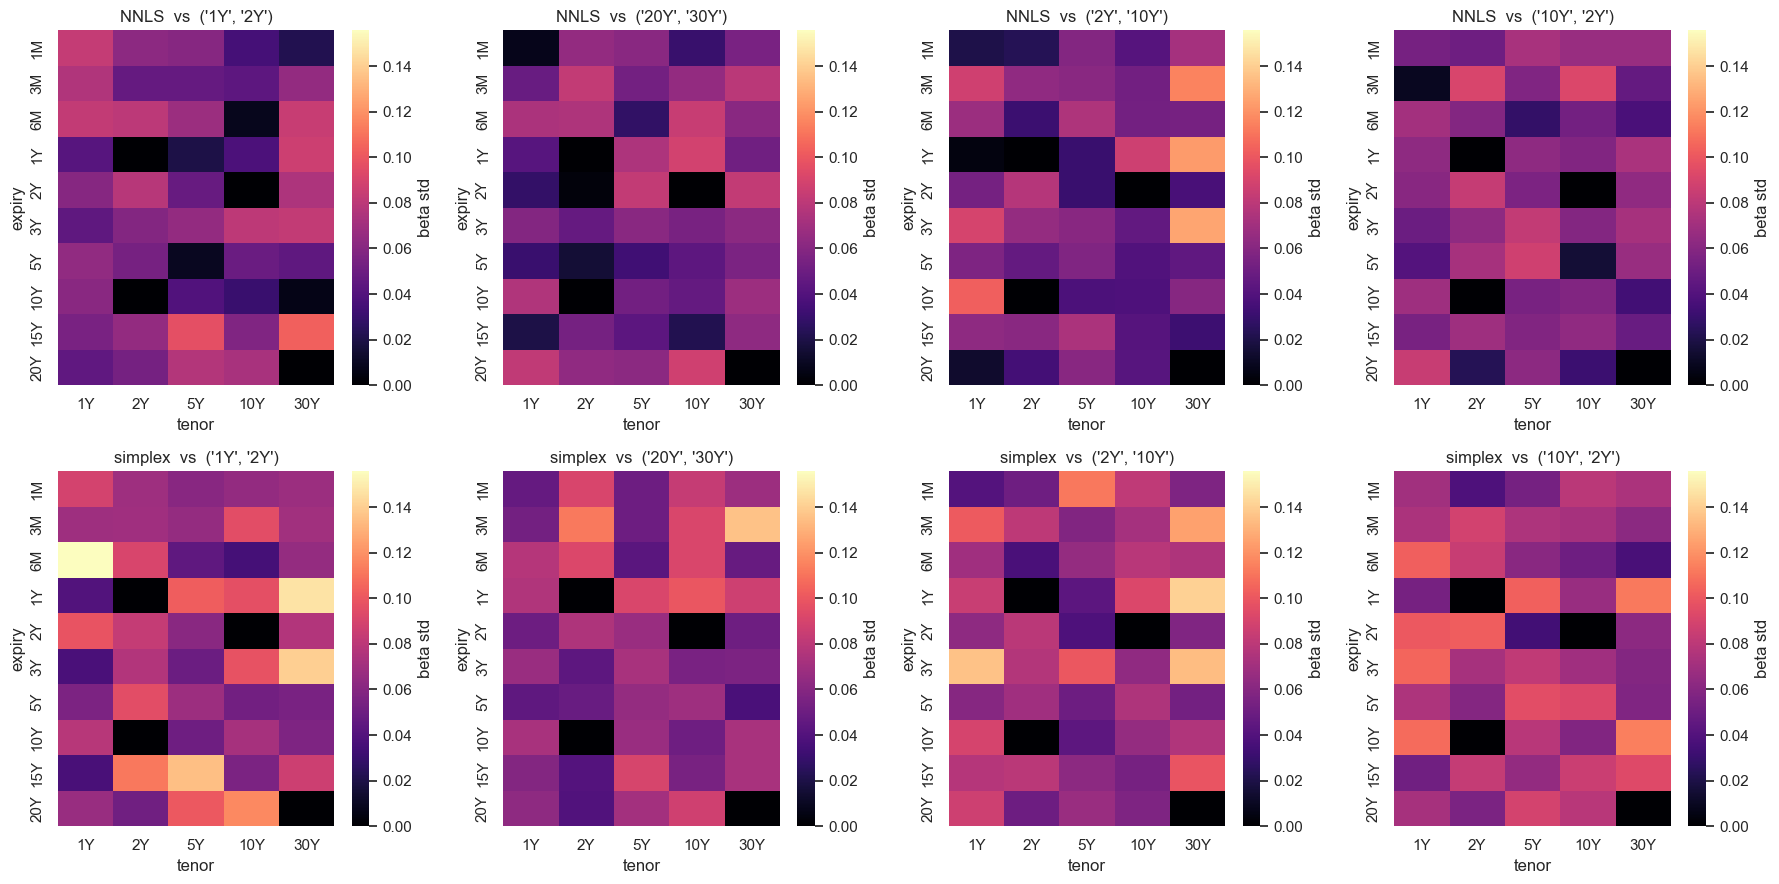

In [6]:
from factors import fit_nnls_rolling, fit_simplex_rolling, beta_stability

# Restrict to the liquid universe for rolling fits (50 cells; keeps simplex
# rolling under ~1 min on mock).
rate_liquid = rate.reindex(
    columns=pd.MultiIndex.from_tuples(LIQUID_UNIVERSE, names=["expiry", "tenor"]),
)
print(f"rolling fits on liquid panel: {rate_liquid.shape}")

print("running NNLS rolling...")
nnls_roll    = fit_nnls_rolling(rate_liquid, greedy_k4, window=126)
print("running simplex rolling (slower)...")
simplex_roll = fit_simplex_rolling(rate_liquid, greedy_k4, window=126)
print(f"NNLS:    {nnls_roll.shape} dates × (cells × anchors)")
print(f"simplex: {simplex_roll.shape} dates × (cells × anchors)")

nnls_std    = beta_stability(nnls_roll, greedy_k4)
simplex_std = beta_stability(simplex_roll, greedy_k4)

print(f"\nmean rolling-beta std per anchor:\n  NNLS:\n{nnls_std.mean().round(4)}")
print(f"  simplex:\n{simplex_std.mean().round(4)}")

# Per-anchor heatmap layout: 2 rows (NNLS / simplex) × K columns
K = len(greedy_k4)
fig, axes = plt.subplots(2, K, figsize=(4.5 * K, 9))
vmax = max(float(nnls_std.values.max()), float(simplex_std.values.max()))
for j, anchor in enumerate(greedy_k4):
    col = f"{anchor[0]}|{anchor[1]}"
    for row_i, (panel, label) in enumerate([(nnls_std, "NNLS"),
                                             (simplex_std, "simplex")]):
        grid = panel[col].unstack(level="tenor")
        grid = grid.reindex(
            index=[e for e in EXPIRY_LABELS if e in grid.index],
            columns=[t for t in TENOR_LABELS if t in grid.columns],
        )
        sns.heatmap(grid, ax=axes[row_i, j], cmap="magma",
                    vmin=0, vmax=vmax, cbar_kws={"label": "beta std"})
        axes[row_i, j].set_title(f"{label}  vs  {anchor}")
        axes[row_i, j].set_xlabel("tenor"); axes[row_i, j].set_ylabel("expiry")
fig.tight_layout()

# Flag simplex (cell, anchor) pairs with std > 0.3
high_std = simplex_std[simplex_std > 0.3].stack()
print(f"\nsimplex (cell, anchor) pairs with rolling std > 0.3: {len(high_std)}")
if len(high_std):
    print(high_std.head(10).round(3))


### 15a. Unified metrics row across all three modes

`anchor_metrics_row(..., mode=...)` always fits all three modes
internally so the row reports `r2_ridge_mean`, `r2_nnls_mean`,
`r2_simplex_mean`, and `hull_breach_pct` regardless of which mode
is selected as the "headline". Concatenate these rows with the
other tracks' `metrics_table` rows for a single cross-method sheet.


In [7]:
# Run on the liquid panel so the simplex rolling fit inside
# anchor_metrics_row finishes in reasonable time.
rows = []
for m in ("ridge", "nnls", "simplex"):
    row = anchor_metrics_row(rate_liquid, greedy_k4,
                             lam=1e-4, window=126, mode=m)
    rows.append(row)

unified = pd.DataFrame(rows).set_index("method")
unified.round(4)


,variance_retained,loading_sparsity_gini,rolling_stability,hedge_residual_r2,r2_ridge_mean,r2_nnls_mean,r2_simplex_mean,hull_breach_pct
method,,,,,,,,
anchor_ridge_k4_lam0.0001,0.0973,0.5418,0.0000,0.9027,0.0973,0.0953,-0.0954,1.0
anchor_nnls_k4,0.0953,0.6644,0.1504,0.9047,0.0973,0.0953,-0.0954,1.0
anchor_simplex_k4,-0.0954,0.2075,0.7286,1.0954,0.0973,0.0953,-0.0954,1.0


**Reading the unified row.** All three modes report a `hull_breach_pct`
and `r2_*_mean` triplet that lets you spot when the constraint stack
is too tight for the chosen anchors: a high `hull_breach_pct` + a
large `r2_nnls_mean − r2_simplex_mean` gap means the anchor set is
fundamentally unable to span the cube under the convex-combo
assumption, and you should add an anchor (cell 12) before tightening
the constraint further.

This row is shape-compatible with `factors.metrics_table` outputs
from other tracks — concatenate with vanilla / varimax / block /
sparse / separable rows to build the cross-method comparison.


## 16. Anomaly detection — anchor vs surface decoupling

The fits in sections 3–15 are *average* relationships between anchor
moves and cube moves. On specific dates the relationship can break
down — useful to know in real time. Three rolling diagnostics:

* **`anchor_zscore`** — per-anchor strict-past rolling z. Flags dates
  where an anchor moved by an unusual amount versus its recent history.
* **`residual_zscore`** — strict-past rolling z of the per-date residual
  energy (RMS across cells). Flags dates where the regression model
  fits poorly.
* **`anomaly_report`** — combines both. The interesting flag is
  `decoupling`: anchor moved abnormally **and** the rest of the cube
  did not follow. Either the anchor decoupled from the surface (regime
  shift, idiosyncratic event at that cell) or a factor the model can't
  capture moved that day.


In [8]:
from factors import anomaly_report, anchor_zscore, residual_zscore

# Run on the greedy k=4 anchors (re-use from section 7) with a
# 3-month rolling window and the standard 3-sigma threshold.
report = anomaly_report(
    rate, greedy_k4, z_threshold=3.0, lam=1e-4, window=63,
)
print(f"report shape: {report.shape}")
print(f"  anchor anomalies:   {int(report['anchor_anomaly'].sum())}")
print(f"  residual anomalies: {int(report['residual_anomaly'].sum())}")
print(f"  decoupling events:  {int(report['decoupling'].sum())}")

# Combined-surprise rank: dates where BOTH z's are large multiply up.
# We rank on this regardless of whether the 3-sigma flag fired, so the
# demo always surfaces "most-surprising" dates even on mock data.
report = report.assign(
    combined_z=report["max_anchor_z"] * report["residual_z"].clip(lower=0),
)

n_decouple = int(report["decoupling"].sum())
if n_decouple > 0:
    print(f"\ntop {min(10, n_decouple)} decoupling dates "
          f"(anchor moved big AND residual stayed big):")
    top = report[report["decoupling"]].sort_values(
        "combined_z", ascending=False
    ).head(10)
else:
    print("\nno decoupling events fired at z=3; showing top 10 dates "
          "by combined |anchor z| * residual_z (use as monitoring rank):")
    top = report.sort_values("combined_z", ascending=False).head(10)

cols = ["max_anchor_z", "worst_anchor", "residual_z",
        "anchor_anomaly", "residual_anomaly", "decoupling", "combined_z"]
print(top[cols].round(2))


report shape: (436, 6)
  anchor anomalies:   2
  residual anomalies: 2
  decoupling events:  0

no decoupling events fired at z=3; showing top 10 dates by combined |anchor z| * residual_z (use as monitoring rank):
            max_anchor_z worst_anchor  residual_z  anchor_anomaly  \
date                                                                
2020-12-14          2.17       2Y|10Y        4.23           False   
2021-10-11          2.21      20Y|30Y        2.51           False   
2020-05-07          2.69       2Y|10Y        1.89           False   
2021-11-30          1.78      20Y|30Y        2.41           False   
2020-12-15          2.78        1Y|2Y        1.47           False   
2020-06-29          2.16        1Y|2Y        1.82           False   
2021-05-03          2.04       2Y|10Y        1.85           False   
2020-10-14          1.87        1Y|2Y        1.95           False   
2020-06-26          2.03        1Y|2Y        1.78           False   
2021-10-13          1.54   

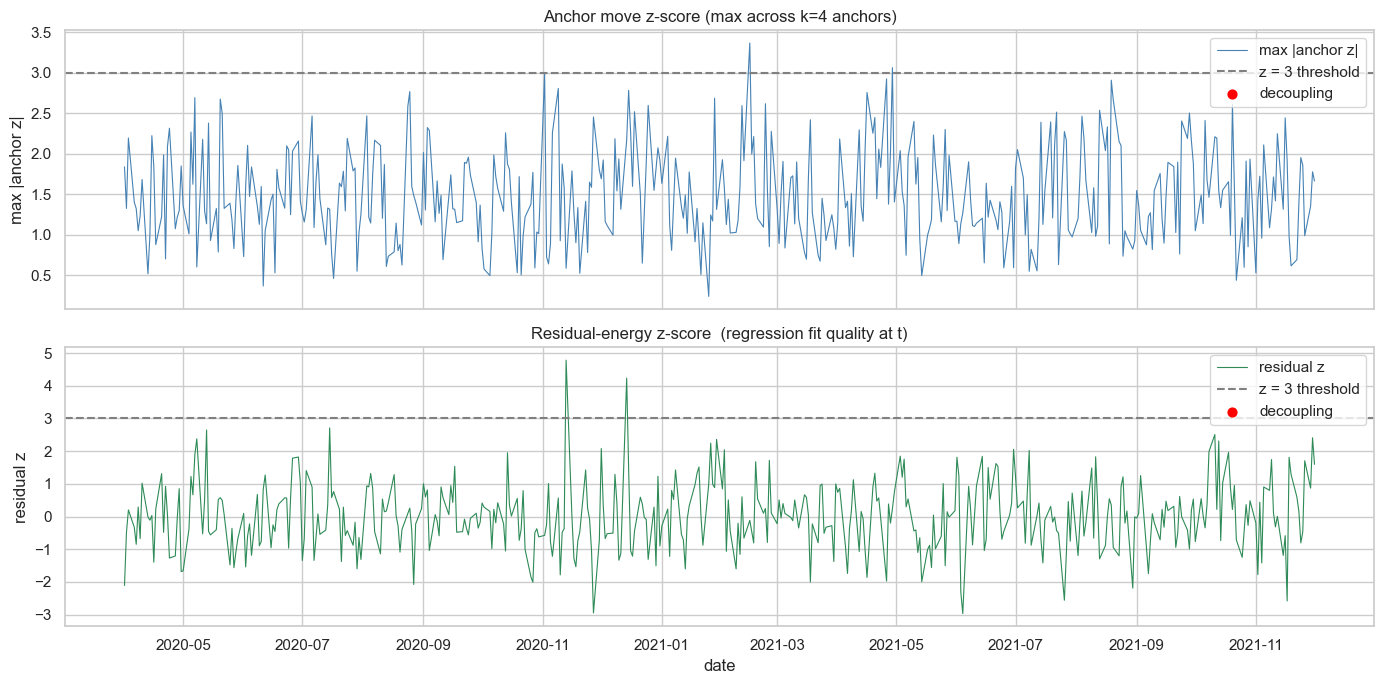

In [9]:
# Visualise the two z-score series with the threshold and decoupling marks.
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(report.index, report["max_anchor_z"], color="steelblue",
             label="max |anchor z|", linewidth=0.8)
axes[0].axhline(3.0, color="grey", linestyle="--", label="z = 3 threshold")
decoup_dates = report.index[report["decoupling"]]
axes[0].scatter(decoup_dates, report.loc[decoup_dates, "max_anchor_z"],
                color="red", s=40, zorder=5, label="decoupling")
axes[0].set_ylabel("max |anchor z|"); axes[0].legend(loc="upper right")
axes[0].set_title("Anchor move z-score (max across k=4 anchors)")

axes[1].plot(report.index, report["residual_z"], color="seagreen",
             label="residual z", linewidth=0.8)
axes[1].axhline(3.0, color="grey", linestyle="--", label="z = 3 threshold")
axes[1].scatter(decoup_dates, report.loc[decoup_dates, "residual_z"],
                color="red", s=40, zorder=5, label="decoupling")
axes[1].set_ylabel("residual z"); axes[1].set_xlabel("date")
axes[1].legend(loc="upper right")
axes[1].set_title("Residual-energy z-score  (regression fit quality at t)")
fig.tight_layout()


drilling into 2020-12-14  (top combined-surprise date (no 3-sigma decoupling fired))
  worst anchor:   2Y|10Y
  max |anchor z|: 2.17
  residual z:     4.23


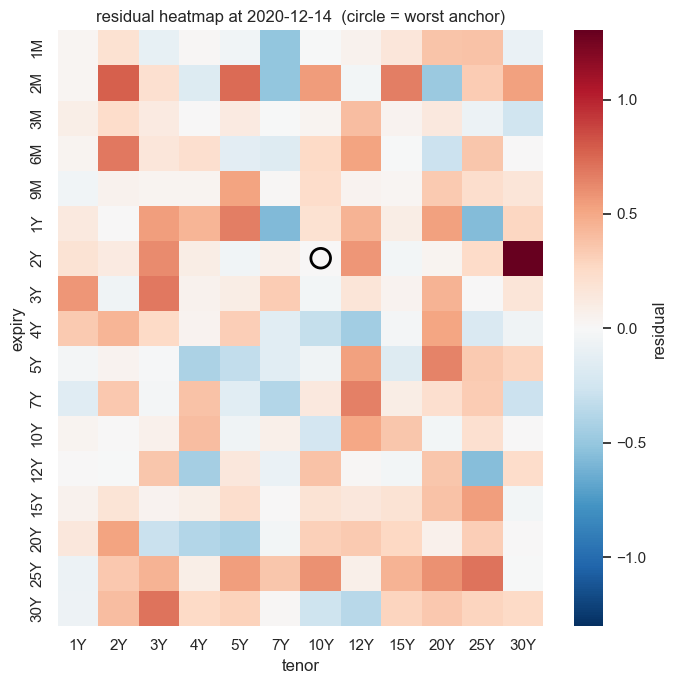

In [10]:
# Drill into a single date: prefer a real decoupling event; on data
# where none fires (e.g. mock OU surface) fall back to the top
# combined-surprise date so the demo still ends with a heatmap.
if int(report["decoupling"].sum()) > 0:
    pick = report[report["decoupling"]].sort_values(
        "combined_z", ascending=False
    ).index[0]
    pick_label = "decoupling event"
else:
    pick = report.sort_values("combined_z", ascending=False).index[0]
    pick_label = "top combined-surprise date (no 3-sigma decoupling fired)"

print(f"drilling into {pick.strftime('%Y-%m-%d')}  ({pick_label})")
print(f"  worst anchor:   {report.loc[pick, 'worst_anchor']}")
print(f"  max |anchor z|: {report.loc[pick, 'max_anchor_z']:.2f}")
print(f"  residual z:     {report.loc[pick, 'residual_z']:.2f}")

ridge_betas_for_drill = fit_ridge(rate, greedy_k4, lam=1e-4)
am_drill = get_anchor_slice(rate, greedy_k4)
resid_pick = (rate.loc[[pick]]
              - am_drill.loc[[pick]].values @ ridge_betas_for_drill.values.T)
grid = resid_pick.iloc[0].unstack(level="tenor")
grid = grid.reindex(
    index=[e for e in EXPIRY_LABELS if e in grid.index],
    columns=[t for t in TENOR_LABELS if t in grid.columns],
)

fig, ax = plt.subplots(figsize=(7, 7))
vmax = float(grid.abs().max().max())
sns.heatmap(grid, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
            cbar_kws={"label": "residual"})
wa = report.loc[pick, "worst_anchor"]
we, wt = wa.split("|")
if we in EXPIRY_LABELS and wt in TENOR_LABELS:
    ax.scatter(TENOR_LABELS.index(wt) + 0.5,
               EXPIRY_LABELS.index(we) + 0.5,
               s=200, marker="o", facecolor="none",
               edgecolor="black", linewidth=2)
ax.set_title(f"residual heatmap at {pick.strftime('%Y-%m-%d')}  "
             f"(circle = worst anchor)")
ax.set_xlabel("tenor"); ax.set_ylabel("expiry")
fig.tight_layout()


**Reading the output.** On the mock rate panel, decoupling events
are rare (mock cells are independent OU processes — there is no
common factor for the anchors to predict, so the residual is roughly
noise-shaped and z rarely exceeds 3 sigma). On real data with
strong factor structure, you'd expect a handful of decoupling events
per year — central-bank surprise days, large repricings localised
to one tenor bucket, settlement glitches, etc.

How to use this in practice:

* **`anchor_anomaly` only** — anchor moved big but the cube moved
  with it (residual_z stays low). Normal regime, just a big day.
* **`residual_anomaly` only** — anchor moves were normal but the cube
  surprised in a way the anchors can't explain. Missing factor; flag
  for anchor reselection.
* **`decoupling`** — both. The most actionable: either the anchor
  cell had an idiosyncratic event (illiquid quote, repricing
  artefact) or a regime shift broke the historical relationship.
  Inspect the residual heatmap above to see *which* part of the cube
  diverged.


## Wrap-up

* `factors.anchor` covers the whole anchor-regression pipeline:
  fit (ridge / NNLS / simplex), per-cell R², rolling beta
  stability, multicollinearity diagnostics, greedy selection,
  constraint-cost heatmap, convex-hull breach flags, hedge-
  allocation tables, a unified metrics row, and per-date
  anomaly / decoupling flags.
* Constraint stack: **ridge** (tightest fit, allows negative
  hedge ratios) → **NNLS** (long-only) → **simplex** (long-only
  + sum-to-one, betas read as a hedge allocation). The cost of
  each layer is visible in `constraint_cost_heatmap` and the
  unified metrics row.
* Anchor selection: greedy is the default. Use
  `convex_hull_flags` to spot regions the current anchor set
  can't span under simplex; greedy-add a single extra anchor in
  that region (section 12).
* Monitoring: `anomaly_report` (section 16) gives per-date
  flags for anchor moves and residual surprises. The
  `decoupling` flag is the main monitoring signal — fold into
  the daily risk report.
* Next: rerun on the *company* `data/mock/rate.pkl` once it's
  swapped in; `LIQUID_UNIVERSE` should match the desk's
  tradeable swap set.
